# Sentiment Classification for Movie Reviews

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk
import os
import string
from tqdm import tqdm
from nltk.corpus import stopwords
from collections import Counter

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


## Load Dataset

In [3]:
# Download dataset folder
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Dataset downloaded to:", path)

# Manually read CSV from downloaded folder
csv_path = os.path.join(path, "IMDB Dataset.csv")
df = pd.read_csv(csv_path)

Dataset downloaded to: C:\Users\hp\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1


In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# Check if there are null values in the dataset
df.isnull().any()

review       False
sentiment    False
dtype: bool

Since there is no null values in the data there is no need for imputation

## Basic Data Analysis

Dataset Shape: (50000, 2)


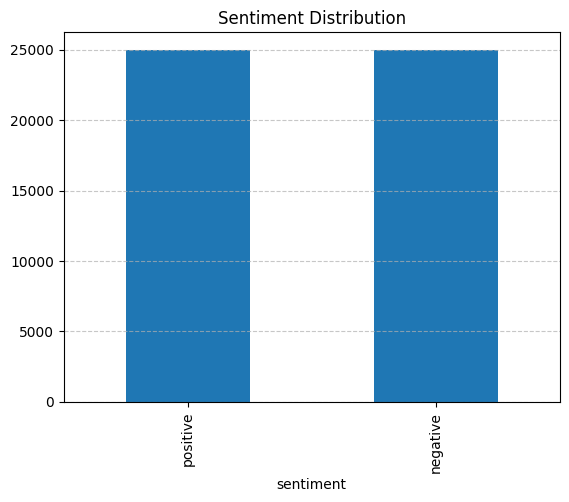

In [6]:
# Dataset info
print(f'Dataset Shape: {df.shape}')


# Visualize label distribution
df['sentiment'].value_counts().plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Sentiment Distribution')
plt.show()

Both the positive and negative classes have same count, so there is no need for class imbalance correction

In [7]:
# Compute number of sentences and words for each review
df["num_sentences"] = df["review"].apply(lambda x: len(sent_tokenize(x)))
df["num_words"] = df["review"].apply(lambda x: len(word_tokenize(x)))
class_stats = df.groupby("sentiment")[["num_sentences", "num_words"]].agg(["mean", "median", "max", "min"])

display(class_stats)
print("Correlation between review length and classes")
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})
display(df[["num_words", "num_sentences", "label"]].corr())

num_sentences                  num_words                 
                   mean median  max min       mean median   max min
sentiment                                                          
negative       11.02688    9.0  118   1  278.60944  211.0  1936   8
positive       10.45600    9.0  282   1  280.35800  207.0  2911  11

Correlation between review length and classes


,num_words,num_sentences,label
num_words,1.000000,0.805764,0.004204
num_sentences,0.805764,1.000000,-0.036129
label,0.004204,-0.036129,1.000000


There no signifcant variation between the classes for sentence and word counts.

### Overview of words in the dataset

In [9]:
top_words_per_class = {}

for cls in df['sentiment'].unique():
    reviews = df[df['sentiment'] == cls]['review'].astype(str)
    word_counter = Counter()
    for review in tqdm(reviews, desc=f"Processing class {cls}"):
        review = review.lower()
        words = review.split()
        words = [word.strip(string.punctuation) for word in words if word.strip(string.punctuation) not in stop_words and word.strip(string.punctuation)]
        word_counter.update(words)
    
    # Get top 10 words
    top_words_per_class[cls] = word_counter.most_common(10)

# Display
for cls, words in top_words_per_class.items():
    print(f"\nTop 10 words for class {cls}:")
    for word, count in words:
        print(f"{word}: {count}")

Processing class negative: 100%|██████████| 25000/25000 [00:03<00:00, 6773.68it/s]


Top 10 words for class positive:
br: 55263
film: 39412
movie: 36021
one: 26098
like: 17146
good: 14391
great: 12731
story: 12392
see: 11930
time: 11772

Top 10 words for class negative:
br: 58530
movie: 47489
film: 35041
one: 24926
like: 21843
even: 15093
good: 14178
bad: 14117
would: 13647
really: 12254
